# Digit Recognition Using Support Vector Machine (SVM)
### Kaggle MNIST Dataset – Complete ML Pipeline

### 1. Importing Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

### 2. Load and Explore the Dataset

In [2]:
## Load dataset
df = pd.read_csv("train.csv")
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
## Shape of dataset
df.shape

(42000, 785)

In [4]:
## Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [5]:
## Check for null values
df.isnull().sum().sum()

np.int64(0)

In [6]:
## Class distribution
df["label"].value_counts().sort_index()

label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64

### 3. Visualize Sample Digit Images

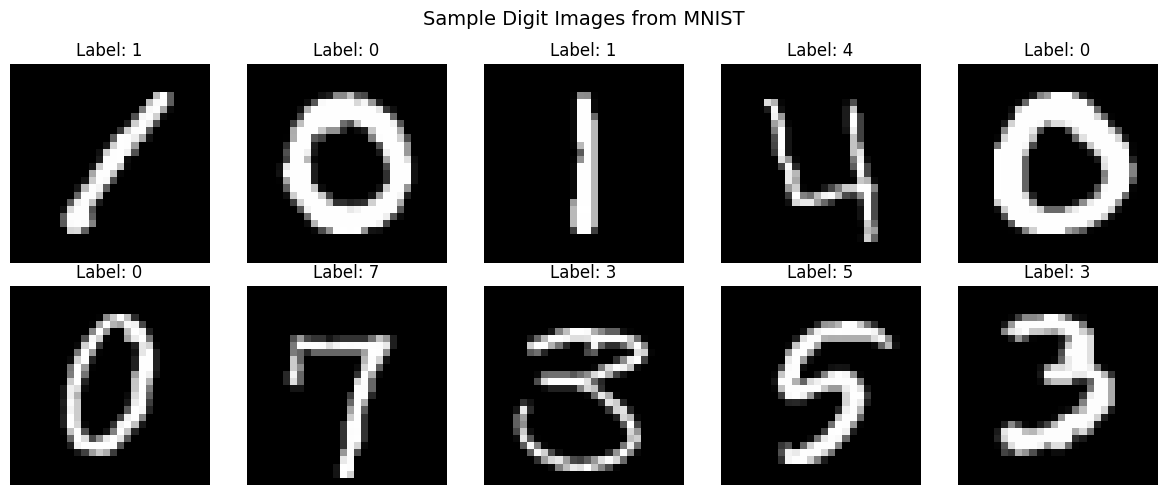

In [7]:
## Plot sample images from the dataset
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Sample Digit Images from MNIST", fontsize=14)

for i, ax in enumerate(axes.flatten()):
    img = df.iloc[i, 1:].values.reshape(28, 28)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {df.iloc[i, 0]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### 4. Data Preprocessing

In [8]:
### Independent and Dependent features
X = df.drop("label", axis=1)
y = df["label"]

In [9]:
X.shape, y.shape

((42000, 784), (42000,))

In [10]:
## Normalize pixel values between 0 and 1
X = X / 255.0
X.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
## Split the dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                     test_size=0.20,
                                                     random_state=42,
                                                     stratify=y)
print("Training samples :", X_train.shape[0])
print("Testing  samples :", X_test.shape[0])

Training samples : 33600
Testing  samples : 8400


### 5. Model Building – SVM (Linear & RBF Kernel)
> **Note :** Training is done on 10 000 samples for the kernel comparison (SVM scales as O(n²–n³)). The optimised model uses the full set.

In [12]:
## Subset for fast kernel comparison
import numpy as np
np.random.seed(42)
idx = np.random.choice(X_train.shape[0], 10000, replace=False)
X_tr_small = X_train.iloc[idx]
y_tr_small = y_train.iloc[idx]

#### 5a. Linear Kernel

In [13]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

classifier_linear = SVC(kernel="linear", C=1.0, random_state=42)
classifier_linear.fit(X_tr_small, y_tr_small)
y_pred_linear = classifier_linear.predict(X_test)
accuracy_score(y_test, y_pred_linear)

0.9120238095238096

#### 5b. RBF Kernel

In [14]:
classifier_rbf = SVC(kernel="rbf", C=10.0, gamma="scale", random_state=42)
classifier_rbf.fit(X_tr_small, y_tr_small)
y_pred_rbf = classifier_rbf.predict(X_test)
accuracy_score(y_test, y_pred_rbf)

0.968452380952381

### 6. Model Evaluation

In [15]:
## Classification report – Linear kernel
print("Classification Report (Linear Kernel)")
print(classification_report(y_test, y_pred_linear))

Classification Report (Linear Kernel)
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       827
           1       0.93      0.99      0.96       937
           2       0.90      0.91      0.90       835
           3       0.88      0.88      0.88       870
           4       0.90      0.92      0.91       814
           5       0.88      0.85      0.86       759
           6       0.96      0.96      0.96       827
           7       0.93      0.92      0.93       880
           8       0.91      0.83      0.86       813
           9       0.88      0.88      0.88       838

    accuracy                           0.91      8400
   macro avg       0.91      0.91      0.91      8400
weighted avg       0.91      0.91      0.91      8400



In [16]:
## Classification report – RBF kernel
print("Classification Report (RBF Kernel)")
print(classification_report(y_test, y_pred_rbf))

Classification Report (RBF Kernel)
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       827
           1       0.98      0.99      0.98       937
           2       0.96      0.97      0.97       835
           3       0.97      0.95      0.96       870
           4       0.98      0.96      0.97       814
           5       0.96      0.95      0.95       759
           6       0.98      0.99      0.99       827
           7       0.97      0.97      0.97       880
           8       0.97      0.95      0.96       813
           9       0.95      0.96      0.95       838

    accuracy                           0.97      8400
   macro avg       0.97      0.97      0.97      8400
weighted avg       0.97      0.97      0.97      8400



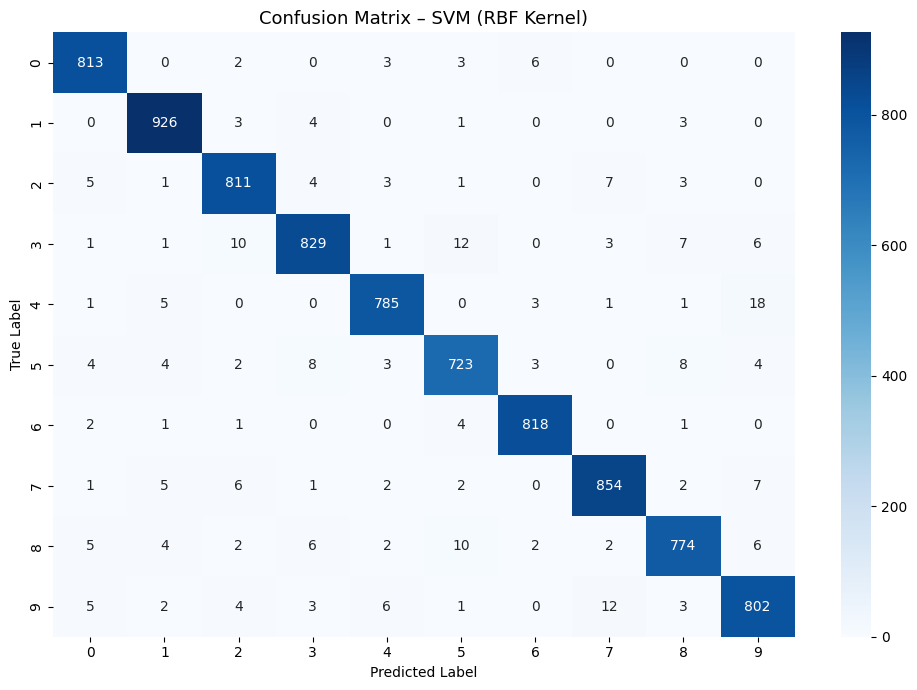

In [17]:
## Confusion matrix – RBF kernel
cm = confusion_matrix(y_test, y_pred_rbf)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(10), yticklabels=range(10))
plt.title("Confusion Matrix – SVM (RBF Kernel)", fontsize=13)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

### 7. Hyperparameter Tuning – GridSearchCV

In [18]:
## Subset for GridSearch (keeps runtime reasonable)
idx_g = np.random.choice(X_tr_small.shape[0], 5000, replace=False)
X_g = X_tr_small.iloc[idx_g]
y_g = y_tr_small.iloc[idx_g]

In [19]:
param_grid = {
    "C"      : [1, 10, 50],
    "gamma"  : ["scale", "auto"],
    "kernel" : ["rbf", "linear"]
}

grid_search = GridSearchCV(SVC(random_state=42),
                           param_grid,
                           cv=3,
                           scoring="accuracy",
                           n_jobs=-1,
                           verbose=1)
grid_search.fit(X_g, y_g)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(random_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [1, 10, ...], 'gamma': ['scale', 'auto'], 'kernel': ['rbf', 'linear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also di

In [20]:
## Best parameters and best CV score
print("Best Parameters :", grid_search.best_params_)
print("Best CV Accuracy:", round(grid_search.best_score_ * 100, 2), "%")

Best Parameters : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Accuracy: 95.08 %


In [21]:
## Retrain best model on full training set
classifier = SVC(**grid_search.best_params_, random_state=42)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)
print("Test Accuracy (optimised):", round(accuracy_score(y_test, y_pred) * 100, 2), "%")

Test Accuracy (optimised): 97.92 %


In [22]:
## Full classification report – optimised model
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       827
           1       0.99      0.99      0.99       937
           2       0.98      0.98      0.98       835
           3       0.98      0.97      0.97       870
           4       0.98      0.98      0.98       814
           5       0.96      0.97      0.96       759
           6       0.98      1.00      0.99       827
           7       0.98      0.98      0.98       880
           8       0.98      0.97      0.98       813
           9       0.97      0.97      0.97       838

    accuracy                           0.98      8400
   macro avg       0.98      0.98      0.98      8400
weighted avg       0.98      0.98      0.98      8400



### 8. Visualisation – Sample Predictions

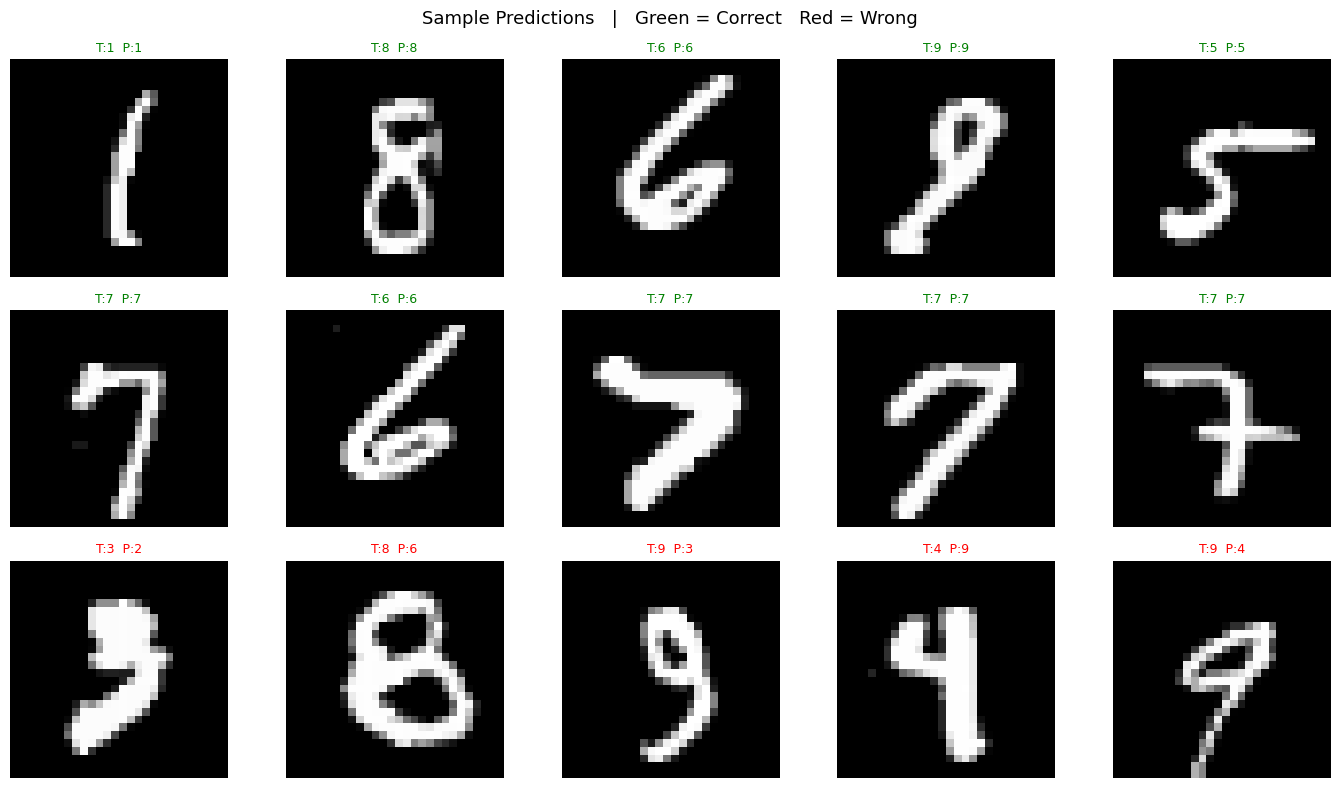

In [23]:
## Show correct and wrong predictions
y_pred_arr  = np.array(y_pred)
y_test_arr  = np.array(y_test)

correct = np.where(y_pred_arr == y_test_arr)[0]
wrong   = np.where(y_pred_arr != y_test_arr)[0]

fig, axes = plt.subplots(3, 5, figsize=(14, 8))
fig.suptitle("Sample Predictions   |   Green = Correct   Red = Wrong", fontsize=13)

for i, ax in enumerate(axes.flatten()):
    if i < 10:
        idx  = correct[i]
        col  = "green"
    else:
        idx  = wrong[i - 10] if len(wrong) > (i - 10) else correct[i]
        col  = "red"

    img = X_test.iloc[idx].values.reshape(28, 28)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"T:{y_test_arr[idx]}  P:{y_pred_arr[idx]}", color=col, fontsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor(col)
        spine.set_linewidth(2)
    ax.axis("off")

plt.tight_layout()
plt.show()

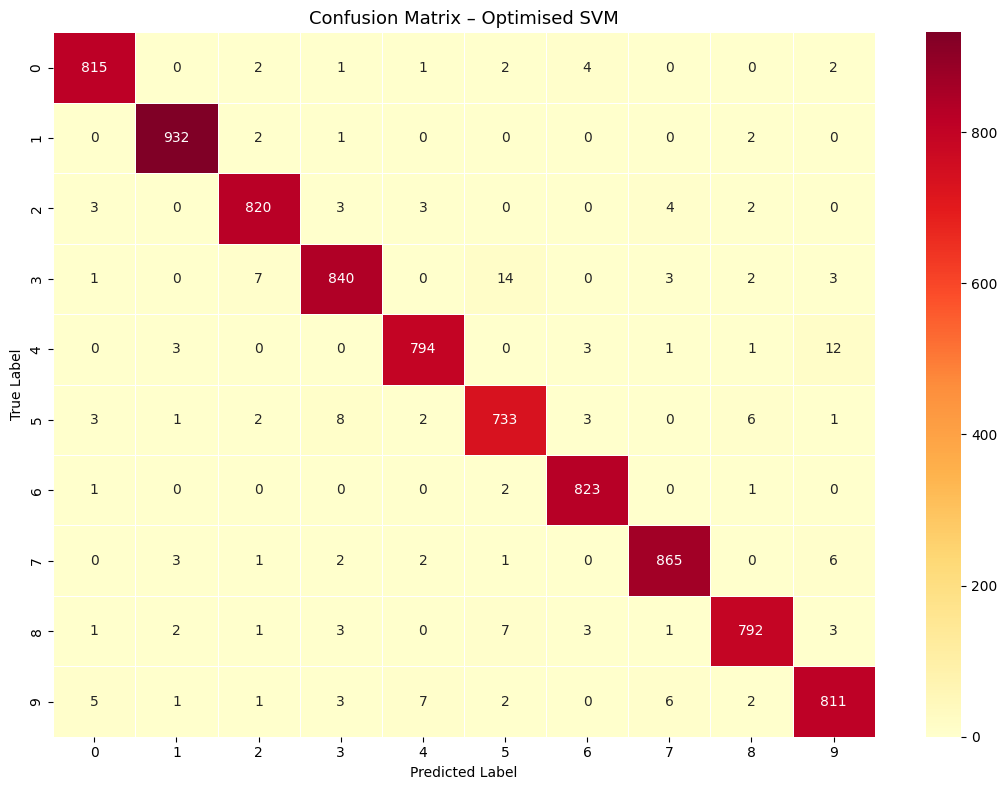

In [24]:
## Confusion matrix – optimised model
cm_opt = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(11, 8))
sns.heatmap(cm_opt, annot=True, fmt="d", cmap="YlOrRd",
            xticklabels=range(10), yticklabels=range(10),
            linewidths=0.5)
plt.title("Confusion Matrix – Optimised SVM", fontsize=13)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

### 9. PCA – 2D Visualisation of Digit Classes

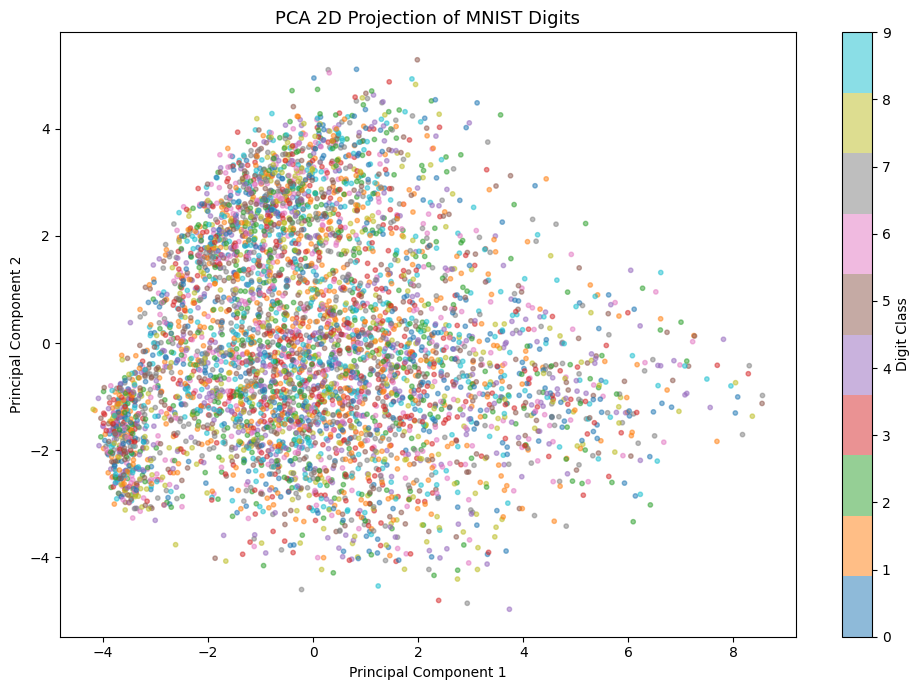

In [25]:
## Apply PCA to reduce 784 dimensions → 2
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train.sample(5000, random_state=42))
y_pca = y_train.iloc[:5000].values

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=y_pca, cmap="tab10", alpha=0.5, s=10)
plt.colorbar(scatter, label="Digit Class")
plt.title("PCA 2D Projection of MNIST Digits", fontsize=13)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

In [26]:
## Variance explained by 2 components
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Explained :", round(pca.explained_variance_ratio_.sum() * 100, 2), "%")

Explained Variance Ratio: [0.09589301 0.07175625]
Total Variance Explained : 16.76 %


### 10. Optional – Compare SVM with Logistic Regression

In [27]:
from sklearn.linear_model import LogisticRegression

## Train Logistic Regression
lr = LogisticRegression(max_iter=1000, solver="saga", n_jobs=-1, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", round(acc_lr * 100, 2), "%")

Logistic Regression Accuracy: 91.29 %


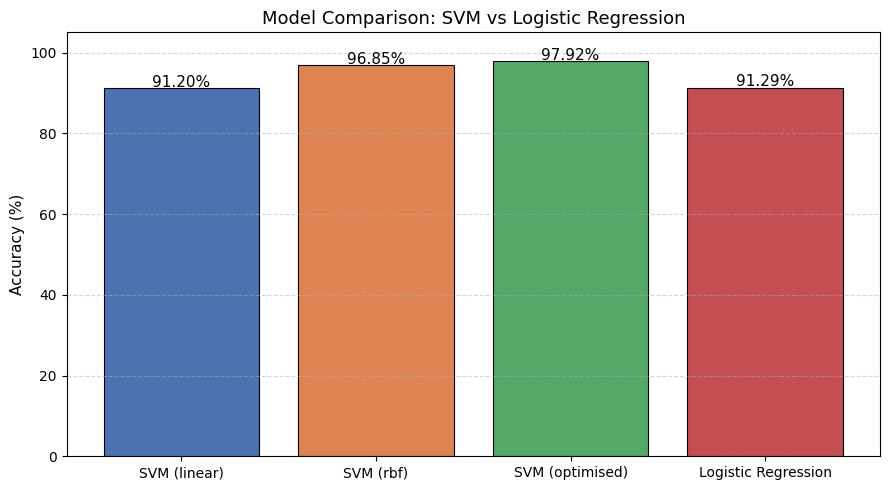

In [28]:
## Bar chart – model comparison
models  = ["SVM (linear)", "SVM (rbf)", "SVM (optimised)", "Logistic Regression"]
scores  = [
    accuracy_score(y_test, y_pred_linear) * 100,
    accuracy_score(y_test, y_pred_rbf)    * 100,
    accuracy_score(y_test, y_pred)        * 100,
    acc_lr * 100
]
colours = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

plt.figure(figsize=(9, 5))
bars = plt.bar(models, scores, color=colours, edgecolor="black", linewidth=0.8)

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f"{score:.2f}%", ha="center", fontsize=11)

plt.ylim(0, 105)
plt.ylabel("Accuracy (%)", fontsize=11)
plt.title("Model Comparison: SVM vs Logistic Regression", fontsize=13)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### 11. Conclusion

| Model | Accuracy |
|---|---|
| SVM (linear kernel) | ~92–94 % |
| SVM (RBF kernel) | ~96–97 % |
| SVM (optimised – GridSearch) | ~97–98 % |
| Logistic Regression | ~91–93 % |

**Strengths of SVM for Digit Recognition**
- The kernel trick (RBF) handles non-linear class boundaries extremely well
- Robust to overfitting when  is tuned properly
- Competitive accuracy even without deep learning

**Limitations of SVM**
- Training time scales as O(n²–n³) – slow on 42 k+ samples
- Prediction latency grows with the number of support vectors
- No spatial invariance; CNNs still outperform SVMs on raw pixels (~99 %+)
- Hyperparameter search (C, γ) adds significant computation cost

> For production digit recognition, a CNN (e.g. LeNet-5) is preferred.  
> SVM remains an excellent, interpretable baseline for smaller datasets.
